In [402]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

In [403]:
df = pd.read_csv('wdbc.data', header=None)
print("="*80)
print("BREAST CANCER CLASSIFICATION PROJECT")
print("="*80)
print("\n1. CEL BADANIA I OPIS ZBIORU DANYCH\n")
print(f"Liczba rekordów: {df.shape[0]}")
print(f"Liczba atrybutów: {df.shape[1]}")
print("\nPierwsze 5 rekordów:")
df.head()

BREAST CANCER CLASSIFICATION PROJECT

1. CEL BADANIA I OPIS ZBIORU DANYCH

Liczba rekordów: 569
Liczba atrybutów: 32

Pierwsze 5 rekordów:


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [404]:
column_names = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]
df.columns = column_names

In [405]:
print("\n2. WSTĘPNE PRZETWARZANIE DANYCH\n")
print("Informacje o zbiorze danych:")
df.info()


2. WSTĘPNE PRZETWARZANIE DANYCH

Informacje o zbiorze danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se       

In [406]:
print("\nStatystyki opisowe:")
df.describe().T


Statystyki opisowe:


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


Z racji iż jest tylko 165.7 KB to nie ma sensu zmniejszać pojemnosci, bo data set jest mały

In [407]:
print("\nBrakujące wartości:")
print(df.isna().sum())


Brakujące wartości:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [408]:
print("\nRozkład klas decyzyjnych:")
print(df['diagnosis'].value_counts())


Rozkład klas decyzyjnych:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [409]:
# Zamienimy diagnozę na wartosc boolean ( 0 i 1 )
df['diagnosis']=df['diagnosis'].replace({"B":"0","M":"1"})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [410]:
#wyrzucamy id bo jest nam niepotrzebne
df.drop('id', axis=1, inplace=True)

In [411]:
print("\nIlość duplikatów:")
df.duplicated().sum()


Ilość duplikatów:


np.int64(0)

In [412]:
print("\nIlośc wartości unikatowych:")
df.nunique()


Ilośc wartości unikatowych:


,0
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave_points_mean,542
symmetry_mean,432


# Analiza i eksploracja zależności

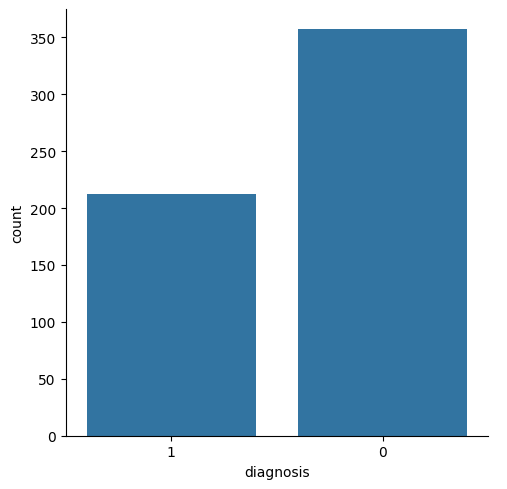

In [413]:
sns.catplot(x='diagnosis',data=df,kind='count')

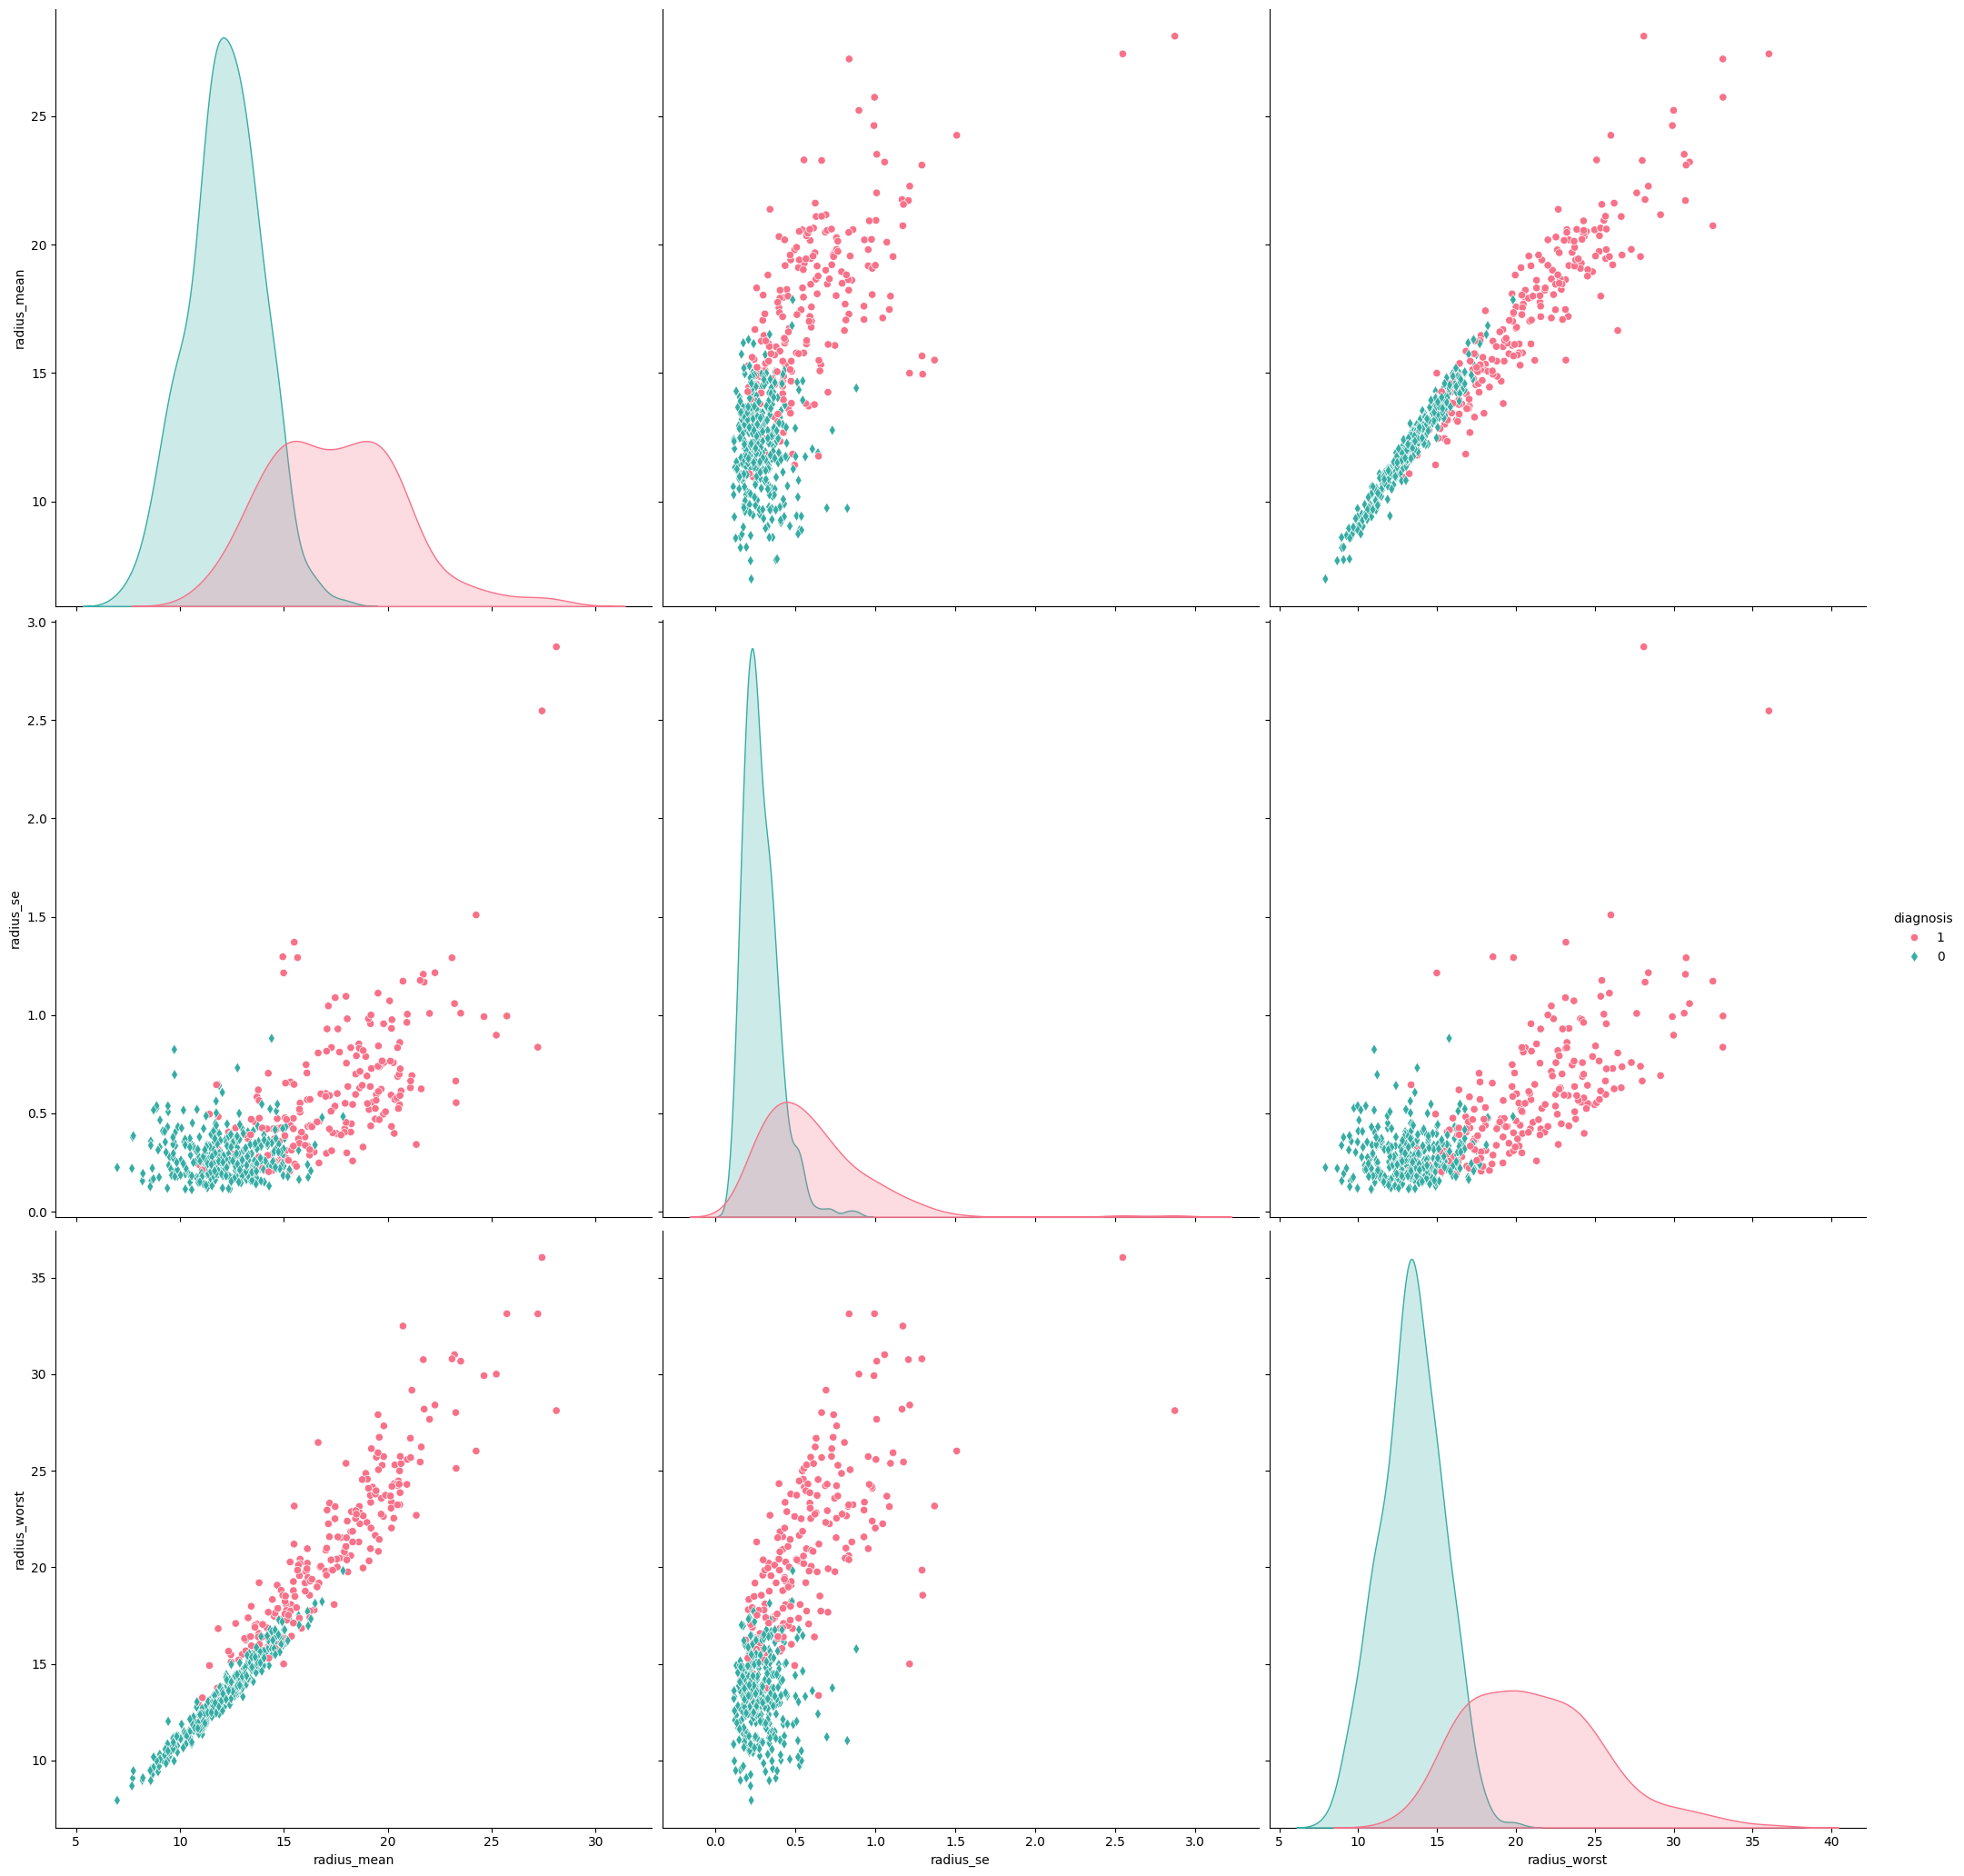

In [414]:
# By radius
radius = df[['radius_mean','radius_se','radius_worst','diagnosis']]
sns.pairplot(radius,hue='diagnosis',palette='husl',markers=['o','d'],height=7)

<Axes: >

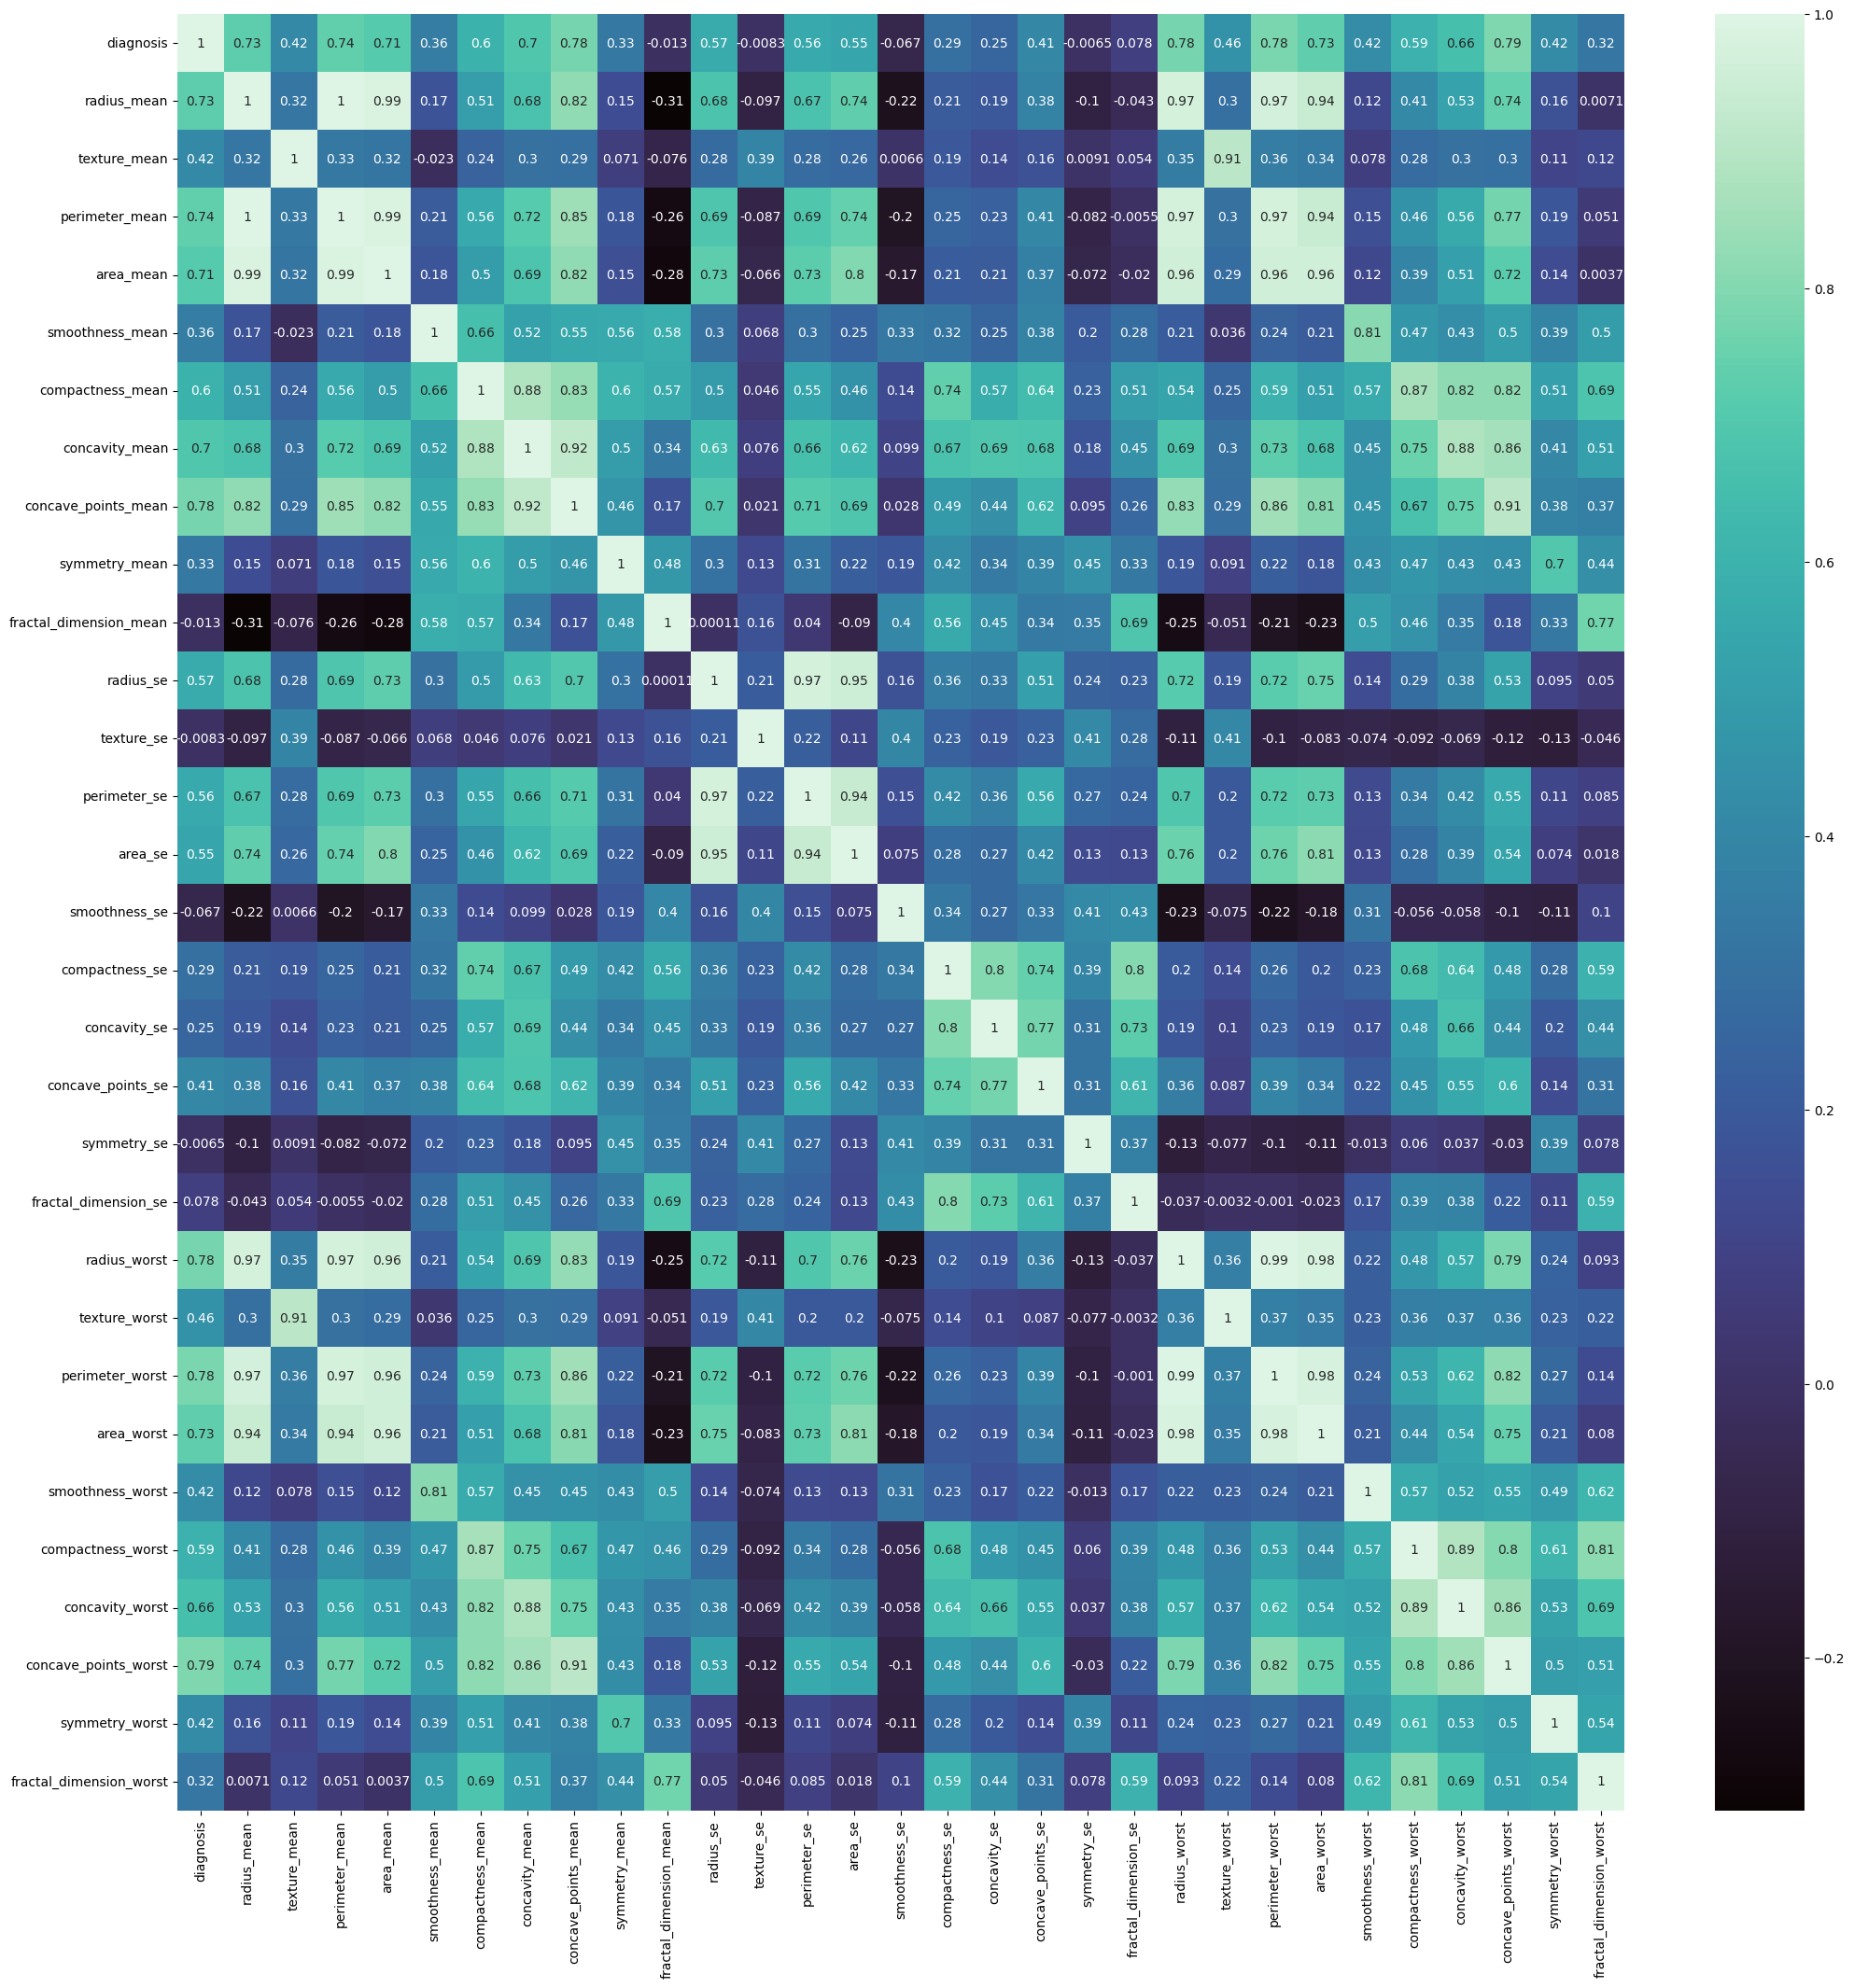

In [415]:
correlation = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(correlation,annot=True,cmap='mako')

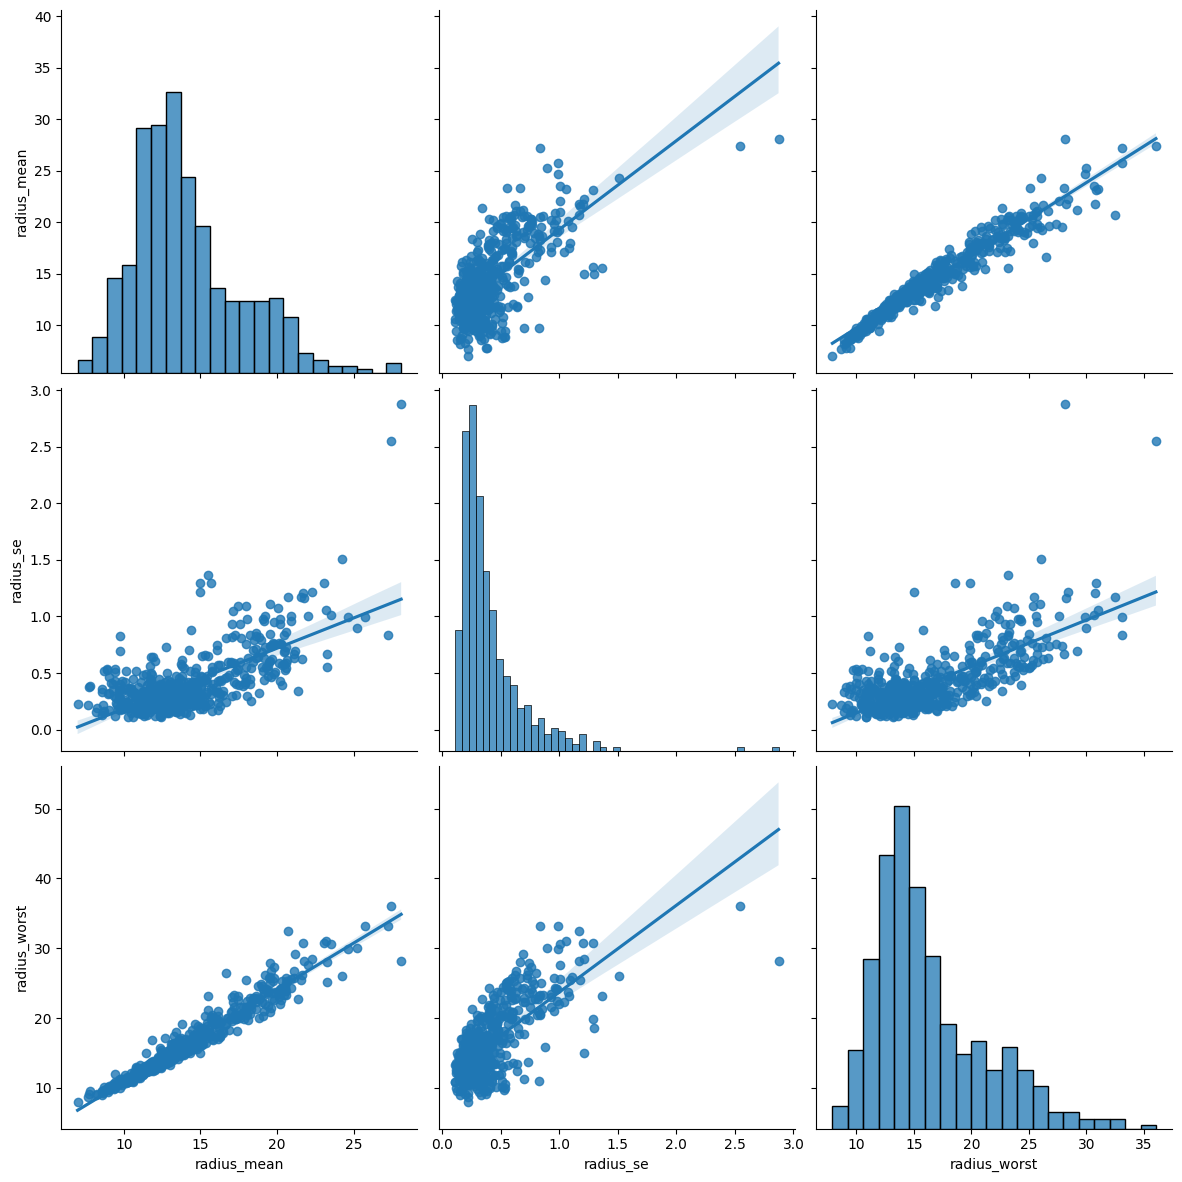

In [416]:
sns.pairplot(radius,kind="reg",height=4)

In [417]:
end = df['diagnosis']
df.drop(labels=['diagnosis'], axis=1,inplace = True)
df.insert(30, 'diagnosis', end)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


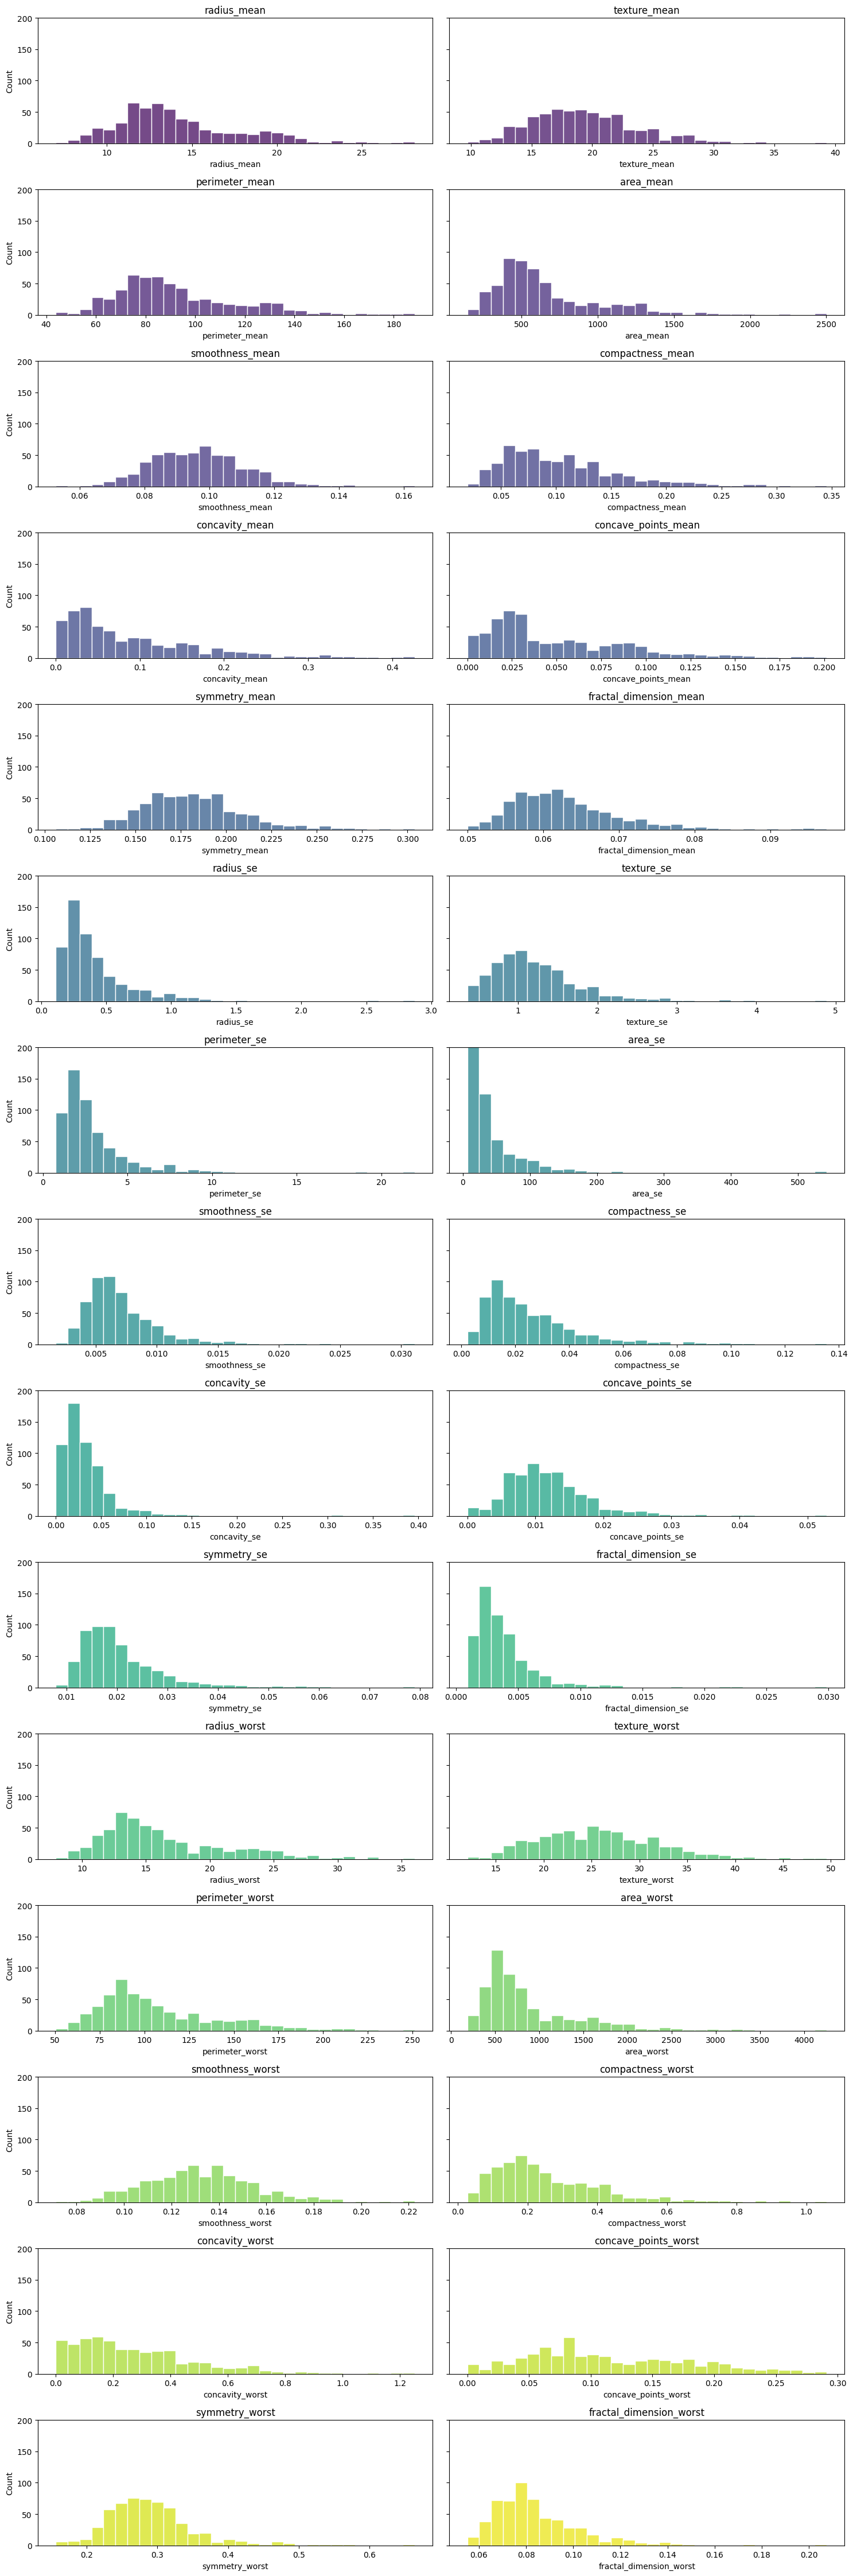

In [418]:
features = df.columns[:-1]
n_features = len(features)
n_rows = int(np.ceil(n_features / 2))
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=2,
    sharey=True,
    figsize=(15, 3 * n_rows)
)

axes = axes.flatten()
palette = sns.color_palette("viridis", n_features)
for i, col in enumerate(features):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        color=palette[i],
        edgecolor="white",
        linewidth=1,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylim(0, 200)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


<Figure size 1000x800 with 0 Axes>

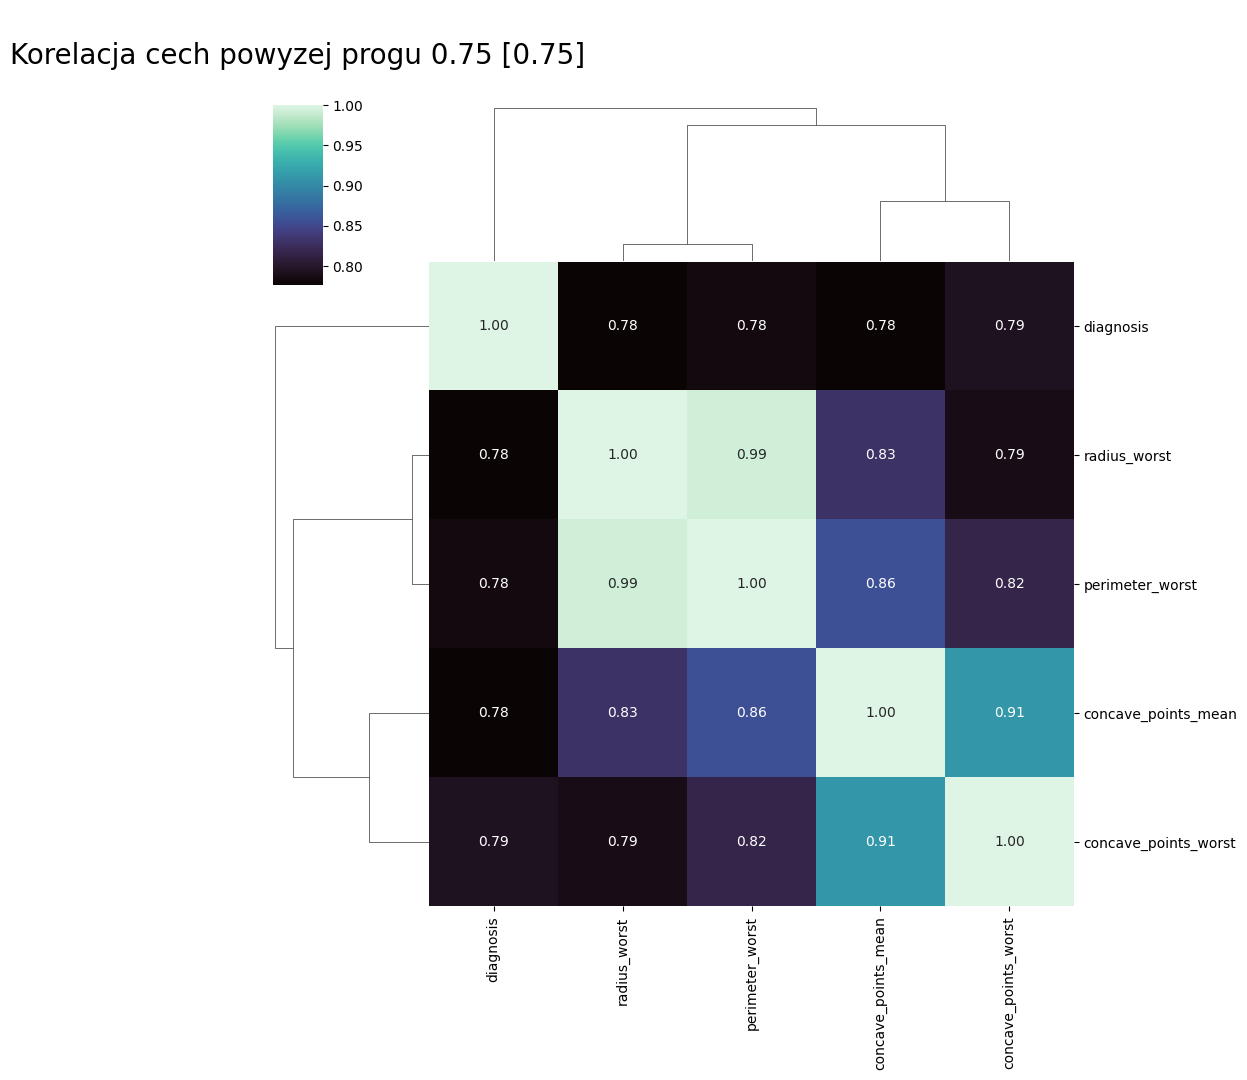

In [419]:
threshold = 0.75
filter = np.abs(correlation["diagnosis"] > threshold)
correlation_features = correlation.columns[filter].tolist()
plt.figure(figsize=(10,8))
sns.clustermap(df[correlation_features].corr(), annot = True, fmt = ".2f", cmap='mako')
plt.title("\nKorelacja cech powyzej progu 0.75 [0.75]\n",fontsize=20)
plt.show()

# Budowa i ewaluacja modeli

In [420]:
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [421]:
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")

Rozmiar zbioru treningowego: 455
Rozmiar zbioru testowego: 114


In [422]:
print("\nStandardyzacja danych:")
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
X_train


Standardyzacja danych:


array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

In [423]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# Lista na wyniki (żeby zbierać dane jak w oryginale)
Results_Recall = {}

def choose_algorithm(model, model_name, X_train, y_train):
    print(f"\n{'='*60}")
    print(f"ANALIZA MODELU: {model_name}")
    print(f"{'='*60}")
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model,X_train, y_train, cv=kfold, scoring='recall')
    mean_recall = cv_scores.mean()
    print(f"--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---")
    print(f"Średnia Czułość (Recall): {mean_recall*100:.2f}%")
    print(f"Stabilność modelu: +/- {cv_scores.std()*100:.2f}%")
    print()

    Results_Recall[model_name] = mean_recall * 100

    return model, mean_recall

def train_test_algorithm(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    test_recall = recall_score(y_test, predictions)
    test_acc = accuracy_score(y_test, predictions)

    print(f"\n--- WYNIKI KOŃCOWE (Na zbiorze testowym) ---")
    print(f"Czułość (Recall): {test_recall*100:.2f}%  <-- Tyle % chorych wykryliśmy")
    print(f"Dokładność (Acc): {test_acc*100:.2f}%")

    cm = confusion_matrix(y_test, predictions)

    group_names = ["TN (Prawdziwie Zdrowy)", "FP (Fałszywy Alarm)",
                   "FN (NIEWYKRYTY RAK!)", "TP (Wykryty Rak)"]

    group_counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]

    cm_sum = np.sum(cm)
    if cm_sum == 0:
        group_percentages = ['0.00%'] * 4
    else:
        group_percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/cm_sum]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=labels, fmt="", cmap='Greens' if test_recall == 1.0 else 'Blues')
    plt.title(f"Macierz pomyłek - {model_name}")
    plt.ylabel('Prawda (Stan pacjenta)')
    plt.xlabel('Werdykt Modelu')
    plt.show()

    return test_recall

# Wyniki

In [424]:
models = {}

In [425]:
model1 = RandomForestClassifier(n_estimators=100,random_state=42)
choose_algorithm(model1, "Random Forest", X_train, y_train)

models['Random Forest'] = model1


ANALIZA MODELU: Random Forest
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 92.94%
Stabilność modelu: +/- 3.53%



In [426]:
model_2 = DecisionTreeClassifier(random_state=42)
choose_algorithm(model_2, "Decision Tree", X_train, y_train)

models['Decision Tree'] = model_2


ANALIZA MODELU: Decision Tree
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 91.14%
Stabilność modelu: +/- 4.90%



In [427]:
model_3 = KNeighborsClassifier(n_neighbors=2)
choose_algorithm(model_3, "K Nearest Neighbors", X_train, y_train)

models['K Nearest Neighbors'] = model_3


ANALIZA MODELU: K Nearest Neighbors
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 87.58%
Stabilność modelu: +/- 2.87%



In [428]:
model_4 = LogisticRegression(max_iter=10000)
choose_algorithm(model_4, "Logistic Regression", X_train, y_train)

models['Logistic Regression'] = model_4


ANALIZA MODELU: Logistic Regression
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 93.48%
Stabilność modelu: +/- 4.35%



In [429]:
model_5 = GaussianNB()
choose_algorithm(model_5, "Naive Bayes", X_train, y_train)

models['Naive Bayes'] = model_5


ANALIZA MODELU: Naive Bayes
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 88.16%
Stabilność modelu: +/- 1.87%



In [430]:
model_6 = XGBClassifier(n_estimators=100,random_state=42)
choose_algorithm(model_6, "XG Boost", X_train, y_train)

models['XG Boost'] = model_6


ANALIZA MODELU: XG Boost
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 94.10%
Stabilność modelu: +/- 2.61%



In [431]:
print("\n6. PODSUMOWANIE WYNIKÓW\n")
Algorithm = ['Random Forest', 'Decision Tree', 'K Nearest Neighbors', 'Logistic Regression', 'Naive Bayes', 'XG Boost']
score = (pd.DataFrame(list(Results_Recall.items()), columns=['Algorithm', 'Recall'])
         .sort_values(by='Recall', ascending=False)
         .reset_index(drop=True))

print(score)


6. PODSUMOWANIE WYNIKÓW

             Algorithm     Recall
0             XG Boost  94.099822
1  Logistic Regression  93.475936
2        Random Forest  92.941176
3        Decision Tree  91.140820
4          Naive Bayes  88.163993
5  K Nearest Neighbors  87.575758


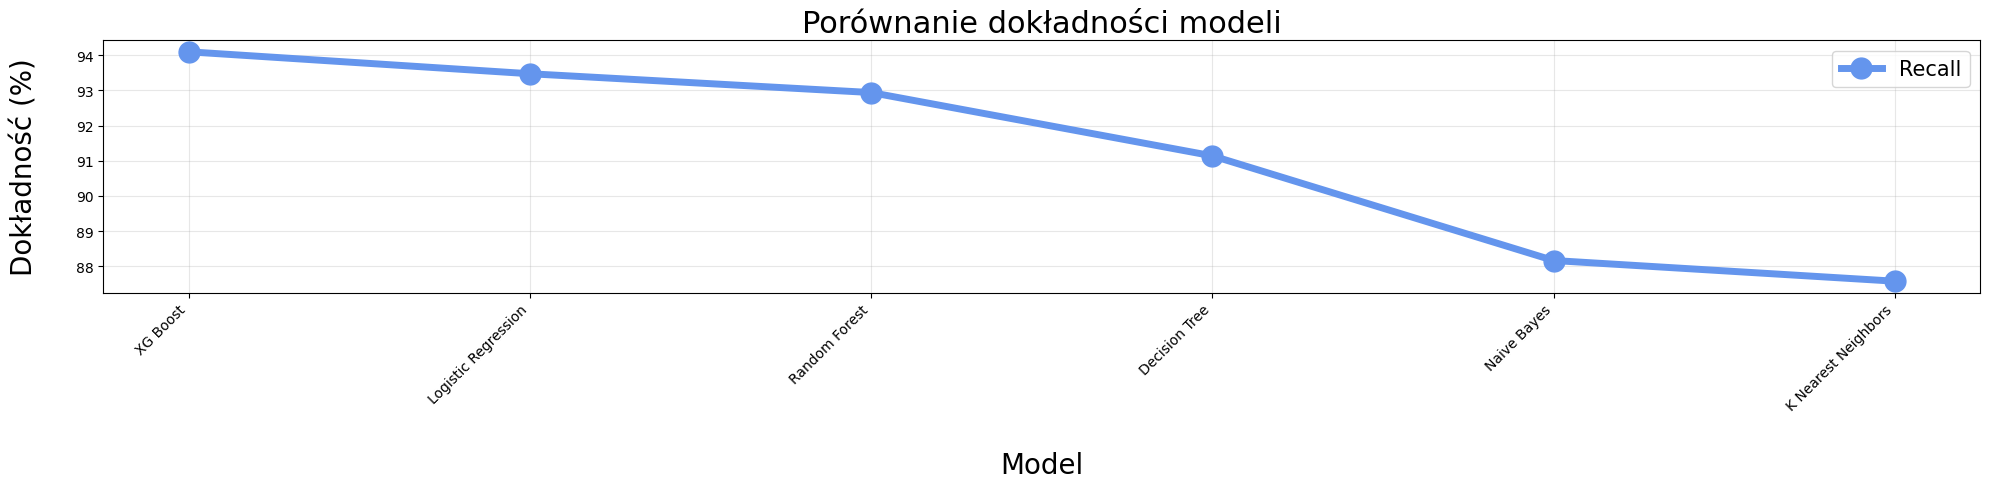

In [432]:
fig = plt.figure(figsize=(20,5))
plt.plot(score.Algorithm, score.Recall, label='Recall', lw=5, color='CornflowerBlue', marker='o', markersize=15)
plt.legend(fontsize=15)
plt.xlabel('\nModel', fontsize=20)
plt.ylabel('Dokładność (%)\n', fontsize=20)
plt.title('Porównanie dokładności modeli', fontsize=22)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


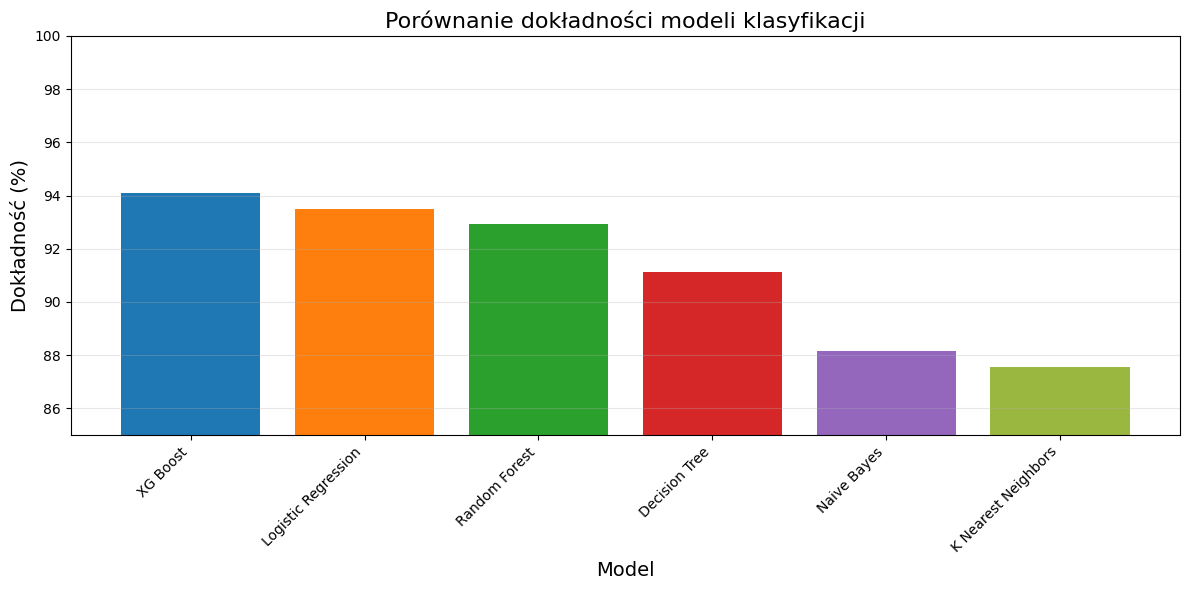

In [433]:
plt.figure(figsize=(12,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd','#9ab73f']
plt.bar(score.Algorithm, score.Recall, color=colors)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Dokładność (%)', fontsize=14)
plt.title('Porównanie dokładności modeli klasyfikacji', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [434]:
print("\n" + "="*80)
print("WNIOSKI")
print("="*80)
print(f"\nNajlepszy model: {score.iloc[0]['Algorithm']}")
print(f"Dokładność najlepszego modelu: {score.iloc[0]['Recall']:.2f}%")
print(f"\nNajsłabszy model: {score.iloc[-1]['Algorithm']}")
print(f"Dokładność najsłabszego modelu: {score.iloc[-1]['Recall']:.2f}%")
print(f"\nRóżnica między najlepszym a najsłabszym modelem: {score.iloc[0]['Recall'] - score.iloc[-1]['Recall']:.2f}%")
print("\nWszystkie modele osiągnęły recall powyżej 88%, co wskazuje na wysoką jakość")
print("predykcji dla tego zbioru danych.  XGBoost i Logistic Regression osiągnęły")
print("najlepsze wyniki, co sugeruje, że dane są odpowiednio separowalne liniowo")
print("lub dobrze opisane przez zespół drzew decyzyjnych.")


WNIOSKI

Najlepszy model: XG Boost
Dokładność najlepszego modelu: 94.10%

Najsłabszy model: K Nearest Neighbors
Dokładność najsłabszego modelu: 87.58%

Różnica między najlepszym a najsłabszym modelem: 6.52%

Wszystkie modele osiągnęły recall powyżej 88%, co wskazuje na wysoką jakość
predykcji dla tego zbioru danych.  XGBoost i Logistic Regression osiągnęły
najlepsze wyniki, co sugeruje, że dane są odpowiednio separowalne liniowo
lub dobrze opisane przez zespół drzew decyzyjnych.


Najskuteczniejszym modelem jest: XG Boost

--- WYNIKI KOŃCOWE (Na zbiorze testowym) ---
Czułość (Recall): 93.02%  <-- Tyle % chorych wykryliśmy
Dokładność (Acc): 95.61%


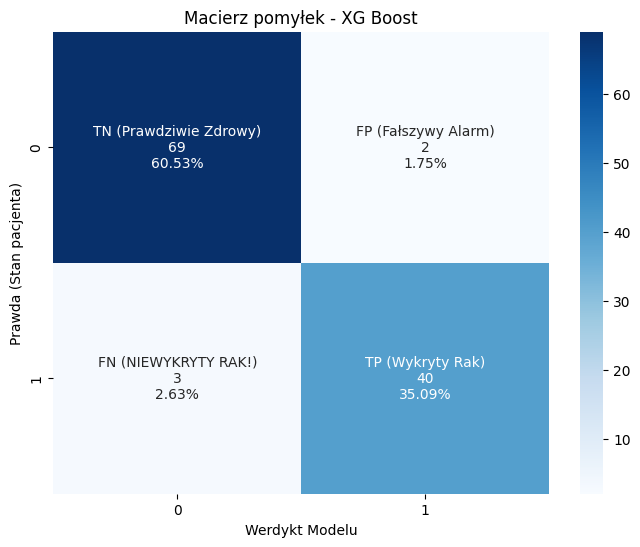

0.9302325581395349

In [435]:
best_algorithm_name = score.iloc[0]['Algorithm']
print(f"Najskuteczniejszym modelem jest: {best_algorithm_name}")
train_test_algorithm(models[best_algorithm_name], best_algorithm_name, X_train, X_test, y_train, y_test)

# Powtórka, natomaist teraz zrobimy inżynierię danych aby dodać nowe kolumny i być może osiągnąć lepszy recall

In [436]:
df_new = df.copy()

In [437]:
EPS = 1e-4

df_new['radius_worst_to_mean_ratio'] = df_new['radius_worst'] / (df_new['radius_mean'] + EPS)
df_new['area_worst_to_mean_ratio'] = df_new['area_worst'] / (df_new['area_mean'] + EPS)
df_new['perimeter_worst_to_mean_ratio'] = df_new['perimeter_worst'] / (df_new['perimeter_mean'] + EPS)
df_new['concavity_worst_to_mean_ratio'] = df_new['concavity_worst'] / (df_new['concavity_mean'] + EPS)
df_new['concave_points_worst_to_mean_ratio'] = df_new['concave_points_worst'] / (df_new['concave_points_mean'] + EPS)

# 2) Range + znormalizowany range (różnica worst-mean i jej skala)
df_new['radius_range'] = df_new['radius_worst'] - df_new['radius_mean']
df_new['area_range'] = df_new['area_worst'] - df_new['area_mean']
df_new['perimeter_range'] = df_new['perimeter_worst'] - df_new['perimeter_mean']
df_new['texture_range'] = df_new['texture_worst'] - df_new['texture_mean']

df_new['radius_range_normalized'] = df_new['radius_range'] / (df_new['radius_mean'] + EPS)
df_new['area_range_normalized'] = df_new['area_range'] / (df_new['area_mean'] + EPS)
df_new['perimeter_range_normalized'] = df_new['perimeter_range'] / (df_new['perimeter_mean'] + EPS)

# 3) CV (zmienność względna): se / mean
df_new['radius_cv'] = df_new['radius_se'] / (df_new['radius_mean'] + EPS)
df_new['area_cv'] = df_new['area_se'] / (df_new['area_mean'] + EPS)
df_new['texture_cv'] = df_new['texture_se'] / (df_new['texture_mean'] + EPS)

# 4) Geometryczne: circularity (4πA / P^2) – miara "okrągłości"
df_new['circularity_mean'] = (4 * np.pi * df_new['area_mean']) / ((df_new['perimeter_mean'] ** 2) + EPS)
df_new['circularity_worst'] = (4 * np.pi * df_new['area_worst']) / ((df_new['perimeter_worst'] ** 2) + EPS)
df_new['circularity_se'] = df_new['circularity_worst'] - df_new['circularity_mean']

# 5) Złożoność/nieregularność: przykładowe wskaźniki z listy
df_new['complexity_mean'] = df_new['compactness_mean'] * df_new['concavity_mean']
df_new['complexity_worst'] = df_new['compactness_worst'] * df_new['concavity_worst']
df_new['complexity_ratio'] = df_new['complexity_worst'] / (df_new['complexity_mean'] + EPS)
df_new['irregularity_index'] = (df_new['compactness_mean'] * df_new['concavity_mean'] * df_new['concave_points_mean']) / (df_new['smoothness_mean'] + EPS)

# 6) Prosta agregacja (średnie po grupach mean/worst/se)
mean_cols = [c for c in df_new.columns if c.endswith('_mean')]
worst_cols = [c for c in df_new.columns if c.endswith('_worst')]
se_cols = [c for c in df_new.columns if c.endswith('_se')]

df_new['mean_features_avg'] = df_new[mean_cols].mean(axis=1)
df_new['worst_features_avg'] = df_new[worst_cols].mean(axis=1)
df_new['se_features_avg'] = df_new[se_cols].mean(axis=1)

df_new['worst_to_mean_overall'] = df_new['worst_features_avg'] / (df_new['mean_features_avg'] + EPS)
df_new['stability_index'] = df_new['se_features_avg'] / (df_new['mean_features_avg'] + EPS)

In [438]:
print("Liczba cech przed FE:", df.drop(['diagnosis'], axis=1).shape[1])
print("Liczba cech po FE:", df_new.drop(['diagnosis'], axis=1).shape[1])

Liczba cech przed FE: 30
Liczba cech po FE: 57


In [439]:
X = df_new.drop(['diagnosis'], axis=1)
y = df_new['diagnosis']
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X, y, test_size=0.2, random_state=42)

In [440]:
y_train_fe = y_train_fe.astype(int)
y_test_fe = y_test_fe.astype(int)

scaler = StandardScaler()
X_train_fe = scaler.fit_transform(X_train_fe)
X_test_fe = scaler.transform(X_test_fe)

In [441]:
models = {}

In [442]:
model7 = RandomForestClassifier(n_estimators=100,random_state=42)
choose_algorithm(model7, "Random Forest", X_train_fe, y_train_fe)

models['Random Forest'] = model7


ANALIZA MODELU: Random Forest
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 92.35%
Stabilność modelu: +/- 5.76%



In [443]:
model8 = DecisionTreeClassifier(random_state=42)
choose_algorithm(model8, "Decision Tree", X_train_fe, y_train_fe)

models['Decision Tree'] = model8


ANALIZA MODELU: Decision Tree
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 93.53%
Stabilność modelu: +/- 3.90%



In [444]:
model9 = KNeighborsClassifier(n_neighbors=2)
choose_algorithm(model9, "K Nearest Neighbors", X_train_fe, y_train_fe)

models['K Nearest Neighbors'] = model9


ANALIZA MODELU: K Nearest Neighbors
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 84.05%
Stabilność modelu: +/- 3.92%



In [445]:
model10 = LogisticRegression(max_iter=10000)
choose_algorithm(model10, "Logistic Regression", X_train_fe, y_train_fe)

models['Logistic Regression'] = model10


ANALIZA MODELU: Logistic Regression
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 96.45%
Stabilność modelu: +/- 2.20%



In [446]:
model11 = GaussianNB()
choose_algorithm(model11, "Naive Bayes", X_train_fe, y_train_fe)

models['Naive Bayes'] = model11


ANALIZA MODELU: Naive Bayes
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 91.14%
Stabilność modelu: +/- 4.13%



In [447]:
model12 = XGBClassifier(n_estimators=100,random_state=42)
choose_algorithm(model12, "XG Boost", X_train_fe, y_train_fe)

models['XG Boost'] = model12


ANALIZA MODELU: XG Boost
--- WYNIKI WALIDACJI (Na zbiorze treningowym) ---
Średnia Czułość (Recall): 94.69%
Stabilność modelu: +/- 2.18%



In [448]:
print("\n6. PODSUMOWANIE WYNIKÓW\n")
Algorithm = ['Random Forest', 'Decision Tree', 'K Nearest Neighbors', 'Logistic Regression', 'Naive Bayes', 'XG Boost']
score = (pd.DataFrame(list(Results_Recall.items()), columns=['Algorithm', 'Recall'])
         .sort_values(by='Recall', ascending=False)
         .reset_index(drop=True))

print(score)


6. PODSUMOWANIE WYNIKÓW

             Algorithm     Recall
0  Logistic Regression  96.452763
1             XG Boost  94.688057
2        Decision Tree  93.529412
3        Random Forest  92.352941
4          Naive Bayes  91.140820
5  K Nearest Neighbors  84.046346


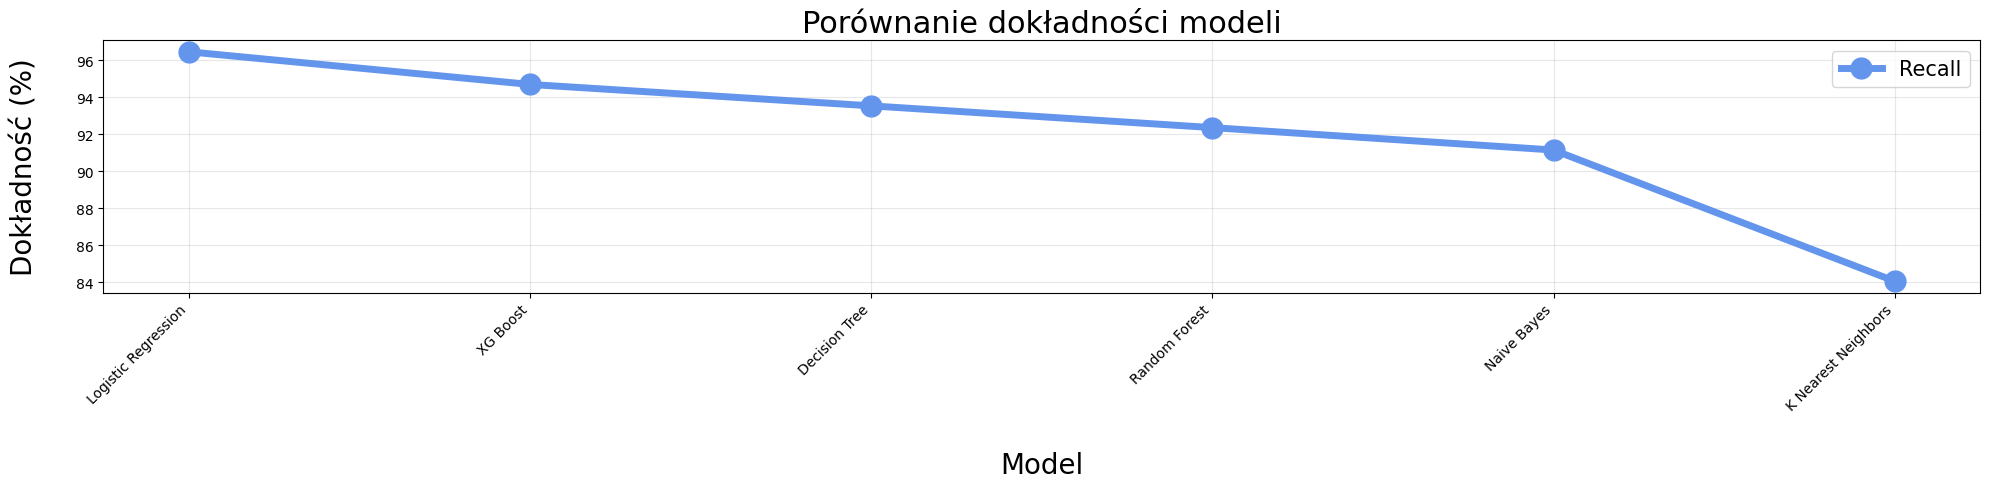

In [449]:
fig = plt.figure(figsize=(20,5))
plt.plot(score.Algorithm, score.Recall, label='Recall', lw=5, color='CornflowerBlue', marker='o', markersize=15)
plt.legend(fontsize=15)
plt.xlabel('\nModel', fontsize=20)
plt.ylabel('Dokładność (%)\n', fontsize=20)
plt.title('Porównanie dokładności modeli', fontsize=22)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


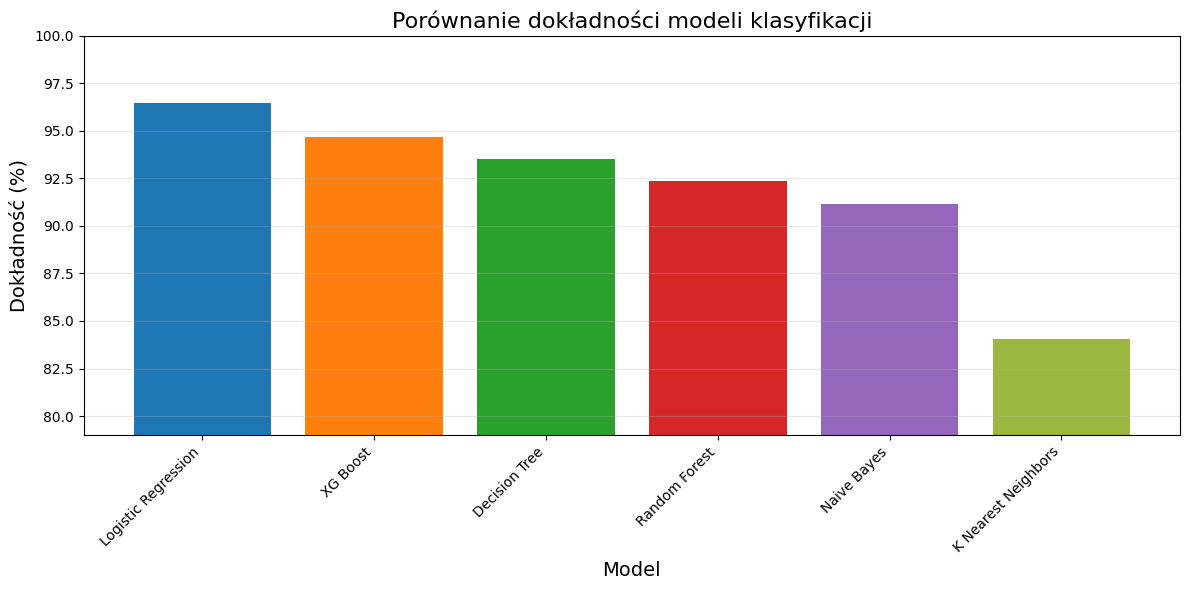

In [450]:
plt.figure(figsize=(12,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd','#9ab73f']
plt.bar(score.Algorithm, score.Recall, color=colors)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Dokładność (%)', fontsize=14)
plt.title('Porównanie dokładności modeli klasyfikacji', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylim(79, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [451]:
print("\n" + "="*80)
print("WNIOSKI")
print("="*80)
print(f"\nNajlepszy model: {score.iloc[0]['Algorithm']}")
print(f"Dokładność najlepszego modelu: {score.iloc[0]['Recall']:.2f}%")
print(f"\nNajsłabszy model: {score.iloc[-1]['Algorithm']}")
print(f"Dokładność najsłabszego modelu: {score.iloc[-1]['Recall']:.2f}%")
print(f"\nRóżnica między najlepszym a najsłabszym modelem: {score.iloc[0]['Recall'] - score.iloc[-1]['Recall']:.2f}%")
print("\nWszystkie modele osiągnęły recall powyżej 88%, co wskazuje na wysoką jakość")
print("predykcji dla tego zbioru danych.  XGBoost i Logistic Regression osiągnęły")
print("najlepsze wyniki, co sugeruje, że dane są odpowiednio separowalne liniowo")
print("lub dobrze opisane przez zespół drzew decyzyjnych.")


WNIOSKI

Najlepszy model: Logistic Regression
Dokładność najlepszego modelu: 96.45%

Najsłabszy model: K Nearest Neighbors
Dokładność najsłabszego modelu: 84.05%

Różnica między najlepszym a najsłabszym modelem: 12.41%

Wszystkie modele osiągnęły recall powyżej 88%, co wskazuje na wysoką jakość
predykcji dla tego zbioru danych.  XGBoost i Logistic Regression osiągnęły
najlepsze wyniki, co sugeruje, że dane są odpowiednio separowalne liniowo
lub dobrze opisane przez zespół drzew decyzyjnych.


Najskuteczniejszym modelem jest: Logistic Regression

--- WYNIKI KOŃCOWE (Na zbiorze testowym) ---
Czułość (Recall): 95.35%  <-- Tyle % chorych wykryliśmy
Dokładność (Acc): 97.37%


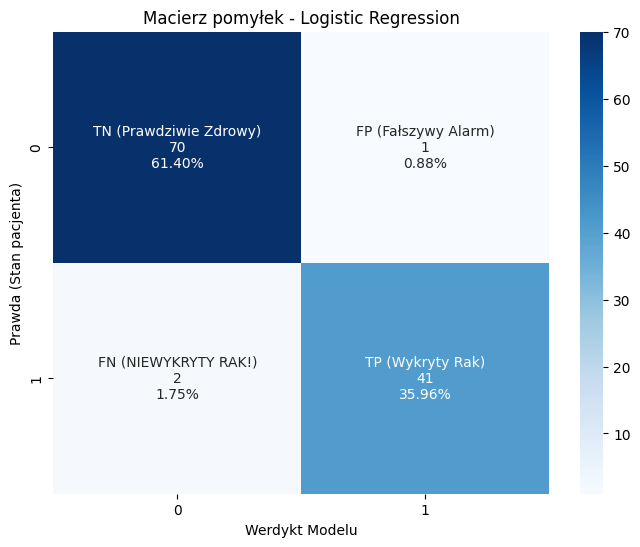

0.9534883720930233

In [452]:
best_algorithm_name = score.iloc[0]['Algorithm']
print(f"Najskuteczniejszym modelem jest: {best_algorithm_name}")
train_test_algorithm(models[best_algorithm_name], best_algorithm_name, X_train, X_test, y_train, y_test)